# LPJ-GUESS FPC and LAI: area-expansion signal vs leaf densification

This diagnostic asks how changes in grid-cell FPC and LAI should inform the
LPJ-GUESS → CLM PFT mapping.

We classify each grid cell, separately for each **CLM-target PFT group**, as:

- **Area-expansion signal:** FPC increases meaningfully, except where the
  joint FPC–LAI response is consistent with FPC saturation.
- **Saturation-consistent leaf densification:** LAI rises materially while
  FPC changes little, both absolutely and relative to the LAI increase, and
  FPC is already high enough for saturation to be plausible.
- **Other / ambiguous:** losses, negligible changes, or changes that do not
  satisfy either diagnostic definition.

LAI is a **grid-cell-area contribution**, so summing LAI across the LPJ PFTs
mapped to one CLM target is appropriate.

> **Interpretive limit:** FPC and grid-cell LAI do not uniquely determine
> physical occupied area and within-canopy leaf density. These categories are
> diagnostic signals, not an exact physical decomposition.
>
> **Caveat**: (Unsaturated) leaf densification can also happen when FPC and LAI increase together, which could slightly over-attributes to expansion.


## 1 · Setup and explicit classification thresholds

The defaults below are deliberately visible and are tested later. They should
not be treated as universal constants.


In [1]:
from pathlib import Path
import warnings

import cartopy.crs as ccrs
import matplotlib.path as mpath
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

warnings.filterwarnings("ignore")
plt.rcParams.update({"font.family": "STIXGeneral","mathtext.fontset": 
                     "stix","axes.titlesize": 13,"axes.labelsize": 11,"font.size": 11,})

DATA = Path("/nird/datapeak/NS9188K/adelez/BRL-FRST-XPSN/data/edit-surfdata/LPJ-GUESS")
FPC_HIST = DATA / "fpc1971to2000.txt"
FPC_FUT = DATA / "GFDL-ESM4_SSP585_fpc2071to2100.txt"
LAI_HIST = DATA / "lai1971to2000.txt"
LAI_FUT = DATA / "GFDL-ESM4_SPP585_lai2071to2100.txt"  # SPP is in the supplied filename

LPJ_NATURAL = ["BNE", "BINE", "BNS", "TeNE", "TeBE", "IBS", "TeBS", "C3G", "HSE", "HSS", "LSE", "LSS", "GRT", "EPDS", "SPDS", "CLM"]

# LPJ PFTs are grouped before diagnosis because these are the CLM targets.
GROUPS = {
    "BoNET": ["BNE", "BINE"],
    "BoNDT (larch)": ["BNS"],
    "BoBDT": ["IBS"],
    "BoBDS shrubs": ["HSE", "HSS", "LSE", "LSS", "EPDS", "SPDS"],
    "aC3": ["C3G", "GRT"],
}

# Primary diagnostic thresholds.
MIN_DFPC = 0.01          # minimum positive FPC change interpreted as meaningful
MIN_DLAI = 0.25          # minimum LAI increase for a densification signal
MAX_DFPC_DENS = 0.05     # FPC must change little in absolute terms
MAX_DFPC_PER_DLAI = 0.10 # and little relative to the LAI increase
SATURATION_FPC = 0.50    # FPC must already be high in either period
DFPC_NOISE_TOL = 0.01    # allow a very small negative dFPC as numerical/noise tolerance

COLORS = {
    "expansion": "#3366A6",
    "densification": "#D9822B",
    "other": "#B7B7B7",
}

print("Primary thresholds")
print(f"  area-expansion signal: dFPC > {MIN_DFPC}, unless classified as densification")
print(f"  densification: dLAI >= {MIN_DLAI}, -{DFPC_NOISE_TOL} <= dFPC <= {MAX_DFPC_DENS},")
print(f"                 positive dFPC/dLAI <= {MAX_DFPC_PER_DLAI}, max(FPC) >= {SATURATION_FPC}")


Primary thresholds
  area-expansion signal: dFPC > 0.01, unless classified as densification
  densification: dLAI >= 0.25, -0.01 <= dFPC <= 0.05,
                 positive dFPC/dLAI <= 0.1, max(FPC) >= 0.5


## 2 · Load and validate the four fields

The loader rejects missing PFT columns, non-numeric values, and duplicate
coordinates. The four arrays must have exactly matching PFTs and grids.


In [2]:
def load_field(path, names=LPJ_NATURAL):
    df = pd.read_csv(path, sep=r"\s+", low_memory=False)
    required = {"Lat", "Lon", *names}
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f"{path}: missing columns {sorted(missing)}")

    numeric_cols = ["Lat", "Lon", *names]
    df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")
    bad_rows = df[numeric_cols].isna().any(axis=1)
    if bad_rows.any():
        raise ValueError(f"{path}: {int(bad_rows.sum())} rows contain missing/non-numeric values")
    if df.duplicated(["Lat", "Lon"]).any():
        raise ValueError(f"{path}: duplicate latitude/longitude rows")

    indexed = df.set_index(["Lat", "Lon"])[names]
    da = xr.DataArray(
        indexed.values,
        coords={"lonlat": indexed.index, "natpft": names},
        dims=["lonlat", "natpft"],
        name=path.stem,
    ).unstack("lonlat")
    return da.rename({"Lat": "lat", "Lon": "lon"}).transpose("natpft", "lat", "lon")


Fh = load_field(FPC_HIST)
Ff = load_field(FPC_FUT)
Lh = load_field(LAI_HIST)
Lf = load_field(LAI_FUT)
Fh, Ff, Lh, Lf = xr.align(Fh, Ff, Lh, Lf, join="exact")

if float(Fh.min()) < 0 or float(Ff.min()) < 0:
    raise ValueError("FPC contains negative values")
if float(Lh.min()) < 0 or float(Lf.min()) < 0:
    raise ValueError("LAI contains negative values")

print("Aligned dimensions:", dict(Fh.sizes))
print(f"Latitude:  {float(Fh.lat.min()):.2f} to {float(Fh.lat.max()):.2f}")
print(f"Longitude: {float(Fh.lon.min()):.2f} to {float(Fh.lon.max()):.2f}")
print("All four fields have identical coordinates and PFT ordering.")

# Cosine-latitude is an approximation to cell area on a regular lat-lon grid.
# Replace this with actual grid-cell areas if they are available.
AREA_WEIGHT = xr.DataArray(
    np.cos(np.deg2rad(Fh.lat)), coords={"lat": Fh.lat}, dims="lat", name="coslat"
).broadcast_like(Fh.isel(natpft=0))


Aligned dimensions: {'natpft': 16, 'lat': 75, 'lon': 638}
Latitude:  45.75 to 83.25
Longitude: -179.75 to 179.75
All four fields have identical coordinates and PFT ordering.


## 3 · Classification functions

A densification classification requires simultaneous evidence of:

1. a material LAI increase;
2. a small absolute FPC response;
3. a small positive FPC response per unit LAI increase; and
4. an already high FPC, making saturation plausible.

The area-expansion class then receives every meaningful positive FPC change
not captured by that saturation test. The masks are mutually exclusive.


In [3]:
def grouped_fields(cols):
    """Sum grid-cell-area contributions to the selected CLM target."""
    return (
        Fh.sel(natpft=cols).sum("natpft", min_count=1),
        Ff.sel(natpft=cols).sum("natpft", min_count=1),
        Lh.sel(natpft=cols).sum("natpft", min_count=1),
        Lf.sel(natpft=cols).sum("natpft", min_count=1),
    )


def classify_change(
    fh, ff, lh, lf,
    min_dfpc=MIN_DFPC,
    min_dlai=MIN_DLAI,
    max_dfpc_dens=MAX_DFPC_DENS,
    max_dfpc_per_dlai=MAX_DFPC_PER_DLAI,
    saturation_fpc=SATURATION_FPC,
    dfpc_noise_tol=DFPC_NOISE_TOL,
):
    valid = np.isfinite(fh) & np.isfinite(ff) & np.isfinite(lh) & np.isfinite(lf)
    dF = (ff - fh).where(valid)
    dL = (lf - lh).where(valid)
    max_fpc = xr.concat([fh, ff], dim="period").max("period", skipna=False)

    # Negative dFPC within tolerance is treated as zero only for the response ratio.
    positive_fpc_response = dF.clip(min=0)
    response = xr.where(dL > 0, positive_fpc_response / dL, np.nan)

    densification = (
        valid
        & (dL >= min_dlai)
        & (dF >= -dfpc_noise_tol)
        & (dF <= max_dfpc_dens)
        & (response <= max_dfpc_per_dlai)
        & (max_fpc >= saturation_fpc)
    )
    expansion = valid & (dF > min_dfpc) & ~densification
    other = valid & ~expansion & ~densification

    return xr.Dataset({
        "dFPC": dF,
        "dLAI": dL,
        "response": response,
        "valid": valid,
        "expansion": expansion,
        "densification": densification,
        "other": other,
    })


def weighted_sum(values, mask):
    return float((values.where(mask) * AREA_WEIGHT).sum(skipna=True))


def weighted_area(mask):
    return float(AREA_WEIGHT.where(mask).sum(skipna=True))


def percent(num, den):
    return 100 * num / den if den > 0 else np.nan


## 4 · Quantitative partition by CLM-target group

Two complementary denominators are reported:

- **positive ΔFPC:** partitioned between area-expansion and densification
  classes; this directly addresses what the FPC increase represents;
- **positive material ΔLAI:** partitioned among area-expansion,
  densification, and other/ambiguous cells; this shows where added leaf area
  occurs without forcing every LAI change into one of the two interpretations.

All sums and cell-area shares use cosine-latitude weights.


In [4]:
summary_rows = []
diagnostics = {}

for group, cols in GROUPS.items():
    ds = classify_change(*grouped_fields(cols))
    diagnostics[group] = ds

    positive_fpc = ds.valid & (ds.dFPC > MIN_DFPC)
    material_lai_gain = ds.valid & (ds.dLAI >= MIN_DLAI)
    classified = ds.expansion | ds.densification

    fpc_total = weighted_sum(ds.dFPC, positive_fpc)
    fpc_exp = weighted_sum(ds.dFPC, positive_fpc & ds.expansion)
    fpc_dens = weighted_sum(ds.dFPC, positive_fpc & ds.densification)

    lai_total = weighted_sum(ds.dLAI, material_lai_gain)
    lai_exp = weighted_sum(ds.dLAI, material_lai_gain & ds.expansion)
    lai_dens = weighted_sum(ds.dLAI, material_lai_gain & ds.densification)
    lai_other = weighted_sum(ds.dLAI, material_lai_gain & ds.other)

    classified_area = weighted_area(classified)
    summary_rows.append({
        "group": group,
        "classified area: expansion %": percent(weighted_area(ds.expansion), classified_area),
        "classified area: densification %": percent(weighted_area(ds.densification), classified_area),
        "+dFPC: expansion %": percent(fpc_exp, fpc_total),
        "+dFPC: densification %": percent(fpc_dens, fpc_total),
        "+dLAI: expansion %": percent(lai_exp, lai_total),
        "+dLAI: densification %": percent(lai_dens, lai_total),
        "+dLAI: other %": percent(lai_other, lai_total),
    })

summary = pd.DataFrame(summary_rows).set_index("group")
display(summary.round(1))

# Reconciliation checks for the partitions shown in the charts.
assert np.allclose(
    summary[["+dFPC: expansion %", "+dFPC: densification %"]].sum(axis=1),
    100,
    atol=0.05,
    equal_nan=True,
)
assert np.allclose(
    summary[["+dLAI: expansion %", "+dLAI: densification %", "+dLAI: other %"]].sum(axis=1),
    100,
    atol=0.05,
    equal_nan=True,
)


,classified area: expansion %,classified area: densification %,+dFPC: expansion %,+dFPC: densification %,+dLAI: expansion %,+dLAI: densification %,+dLAI: other %
group,,,,,,,
BoNET,95.3,4.7,99.7,0.3,96.8,1.9,1.4
BoNDT (larch),99.6,0.4,100.0,0.0,99.8,0.1,0.0
BoBDT,100.0,0.0,100.0,0.0,100.0,0.0,0.0
BoBDS shrubs,100.0,0.0,100.0,0.0,97.1,0.0,2.9
aC3,99.9,0.1,100.0,0.0,99.0,0.1,0.9


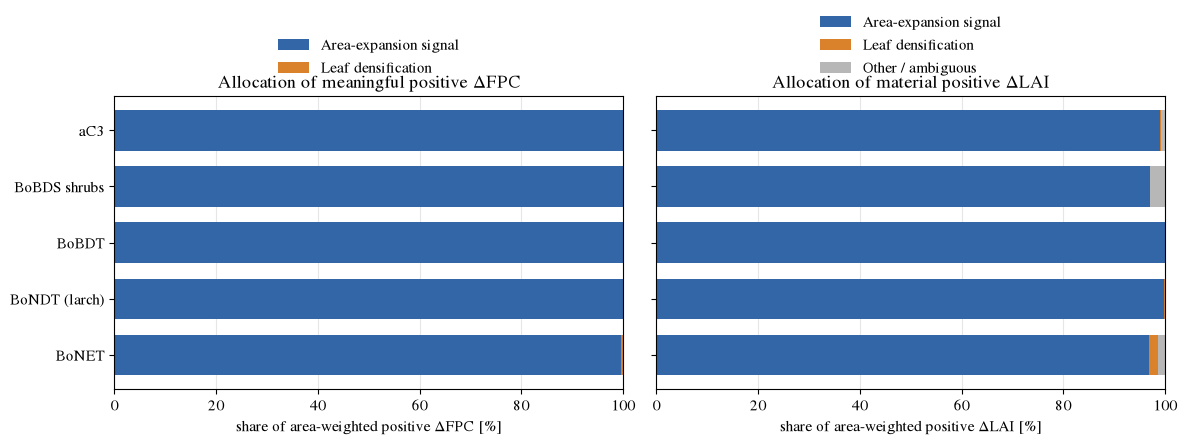

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True)

summary[["+dFPC: expansion %", "+dFPC: densification %"]].rename(columns={
    "+dFPC: expansion %": "Area-expansion signal",
    "+dFPC: densification %": "Leaf densification",
}).plot.barh(
    stacked=True,
    ax=axes[0],
    color=[COLORS["expansion"], COLORS["densification"]],
    width=0.72,
)
axes[0].set_title("Allocation of meaningful positive ΔFPC")
axes[0].set_xlabel("share of area-weighted positive ΔFPC [%]")
axes[0].set_ylabel("")
axes[0].set_xlim(0, 100)
axes[0].legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), frameon=False, ncol=1)

summary[["+dLAI: expansion %", "+dLAI: densification %", "+dLAI: other %"]].rename(columns={
    "+dLAI: expansion %": "Area-expansion signal",
    "+dLAI: densification %": "Leaf densification",
    "+dLAI: other %": "Other / ambiguous",
}).plot.barh(
    stacked=True,
    ax=axes[1],
    color=[COLORS["expansion"], COLORS["densification"], COLORS["other"]],
    width=0.72,
)
axes[1].set_title("Allocation of material positive ΔLAI")
axes[1].set_xlabel("share of area-weighted positive ΔLAI [%]")
axes[1].set_ylabel("")
axes[1].set_xlim(0, 100)
axes[1].legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), frameon=False, ncol=1)

for ax in axes:
    ax.grid(axis="x", color="0.9", linewidth=0.8)
    ax.set_axisbelow(True)

plt.tight_layout()


## 5 · Joint ΔLAI–ΔFPC diagnostic

This plot makes the classification visible rather than hiding it inside a
formula. Densification points must lie in the low-ΔFPC/high-ΔLAI region and
also satisfy the high-FPC saturation condition. A deterministic sample keeps
the figure readable without changing the calculations above.


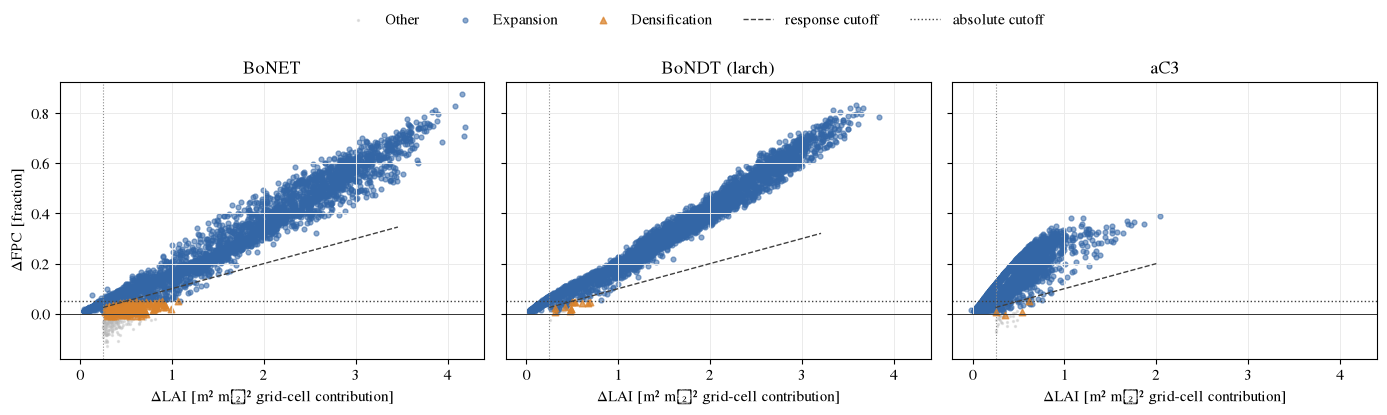

In [5]:
PLOT_GROUPS = ["BoNET", "BoNDT (larch)", "aC3"]
rng = np.random.default_rng(42)
fig, axes = plt.subplots(1, len(PLOT_GROUPS), figsize=(14, 4.2), sharex=True, sharey=True)

for ax, group in zip(axes, PLOT_GROUPS):
    ds = diagnostics[group]
    plot_mask = ds.valid & ((ds.dFPC > MIN_DFPC) | (ds.dLAI >= MIN_DLAI))

    flat = pd.DataFrame({
        "dLAI": ds.dLAI.where(plot_mask).values.ravel(),
        "dFPC": ds.dFPC.where(plot_mask).values.ravel(),
        "expansion": ds.expansion.where(plot_mask, False).values.ravel(),
        "densification": ds.densification.where(plot_mask, False).values.ravel(),
    }).dropna(subset=["dLAI", "dFPC"])
    if len(flat) > 4000:
        flat = flat.iloc[rng.choice(len(flat), 4000, replace=False)]

    other = ~flat.expansion & ~flat.densification
    ax.scatter(flat.loc[other, "dLAI"], flat.loc[other, "dFPC"],
               s=8, c=COLORS["other"], alpha=0.35, marker=".", label="Other")
    ax.scatter(flat.loc[flat.expansion, "dLAI"], flat.loc[flat.expansion, "dFPC"],
               s=12, c=COLORS["expansion"], alpha=0.55, marker="o", label="Expansion")
    ax.scatter(flat.loc[flat.densification, "dLAI"], flat.loc[flat.densification, "dFPC"],
               s=22, c=COLORS["densification"], alpha=0.75, marker="^", label="Densification")

    xline = np.linspace(max(0, MIN_DLAI), max(2, float(flat.dLAI.quantile(0.98))), 100)
    ax.plot(xline, MAX_DFPC_PER_DLAI * xline, color="0.25", lw=1, ls="--",
            label="response cutoff")
    ax.axhline(MAX_DFPC_DENS, color="0.25", lw=1, ls=":", label="absolute cutoff")
    ax.axvline(MIN_DLAI, color="0.55", lw=0.8, ls=":")
    ax.axhline(0, color="0.2", lw=0.7)
    ax.set_title(group)
    ax.set_xlabel("ΔLAI [m² m⁻² grid-cell contribution]")
    ax.grid(color="0.92", linewidth=0.7)

axes[0].set_ylabel("ΔFPC [fraction]")
handles, labels = axes[-1].get_legend_handles_labels()
unique = dict(zip(labels, handles))
fig.legend(unique.values(), unique.keys(), loc="upper center", ncol=5, frameon=False)
plt.tight_layout(rect=[0, 0, 1, 0.90])


## 6 · Spatial patterns

Blue maps show the positive FPC signal assigned to area expansion. Orange
maps show LAI gain only where the joint response is classified as
saturation-consistent leaf densification.


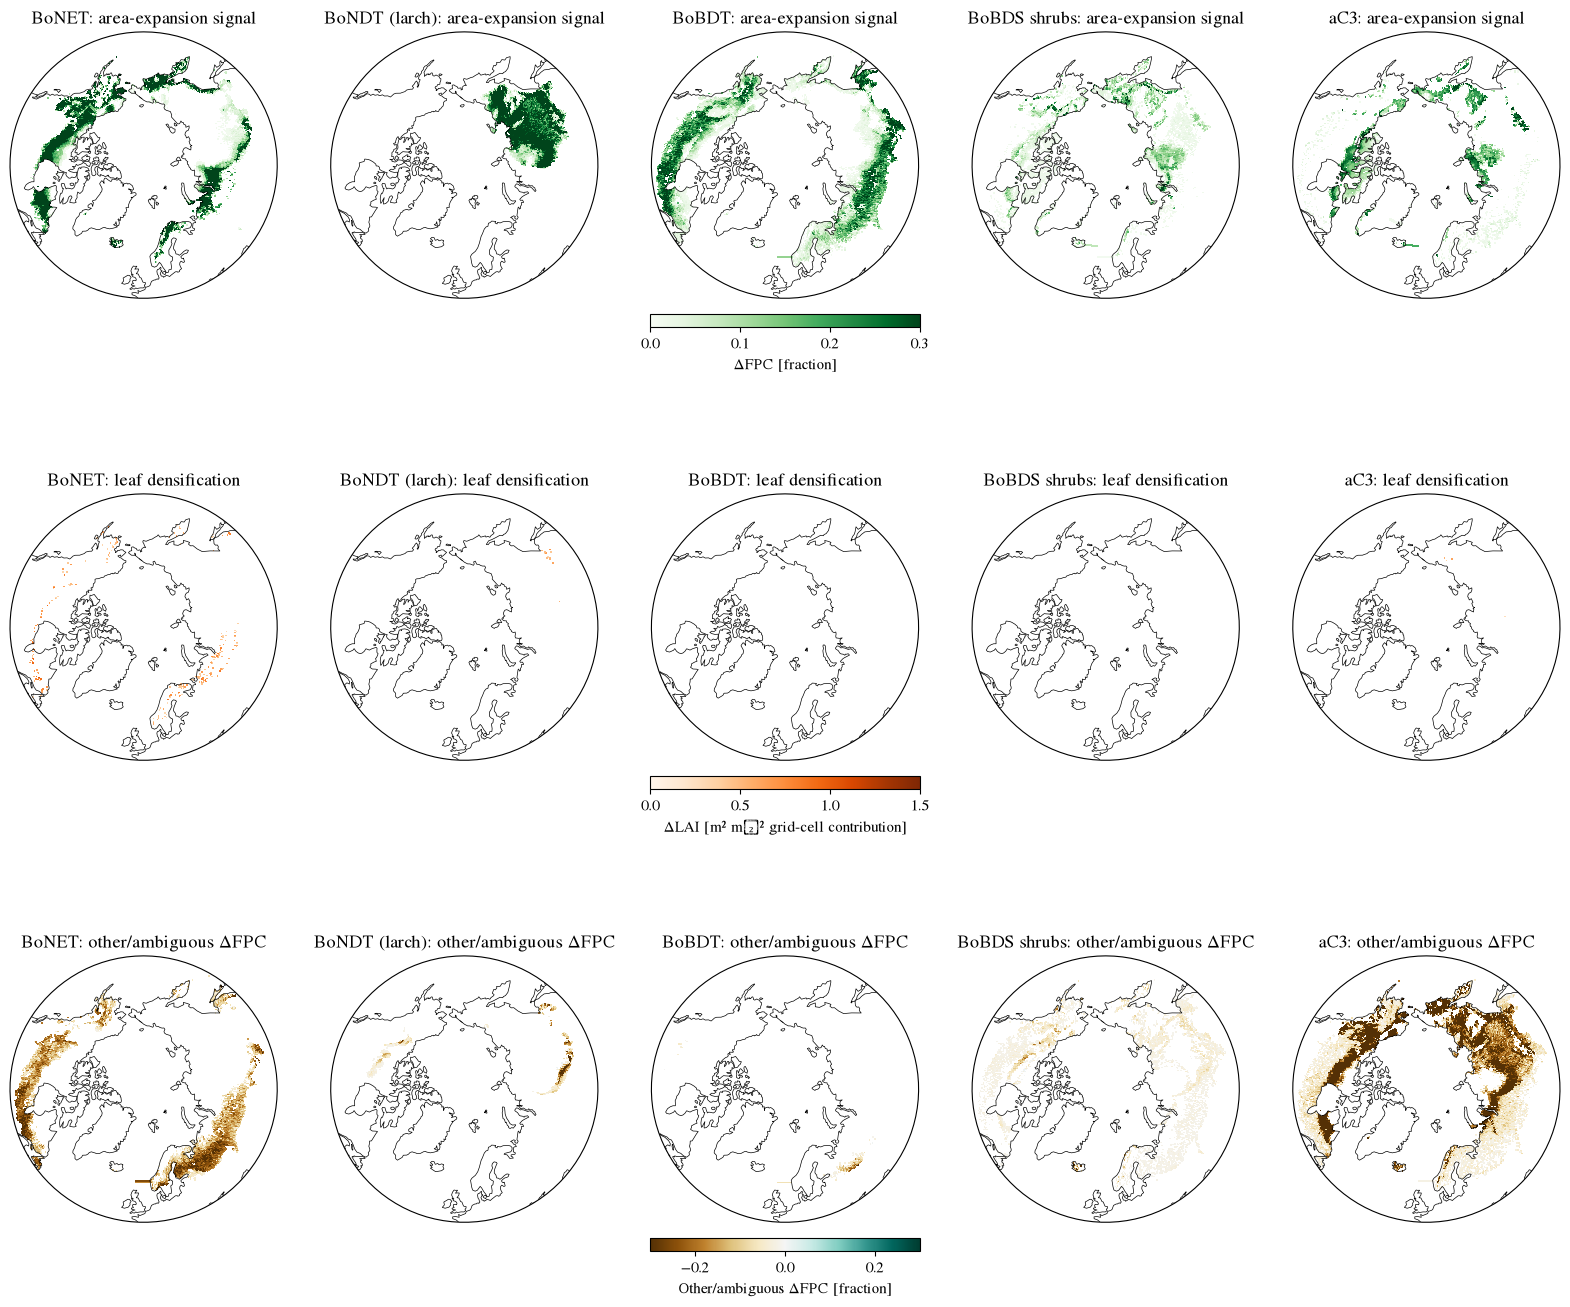

In [13]:
def _circle(ax):
    theta = np.linspace(0, 2 * np.pi, 100)
    boundary = np.vstack([np.sin(theta), np.cos(theta)]).T * 0.5 + [0.5, 0.5]
    ax.set_boundary(mpath.Path(boundary), transform=ax.transAxes)


def polar_map(da, title, ax, cmap, vmin, vmax):
    ax.set_extent([-180, 180, 45, 90], ccrs.PlateCarree())
    _circle(ax)

    artist = da.plot(
        ax=ax,
        x="lon",
        y="lat",
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False,
    )

    ax.coastlines(linewidth=0.5)
    ax.set_title(title)
    return artist


map_groups = ["BoNET", "BoNDT (larch)", "BoBDT", "BoBDS shrubs", "aC3"]

fig, axes = plt.subplots(
    3,
    len(map_groups),
    figsize=(20, 17),
    subplot_kw={"projection": ccrs.Orthographic(0, 90)},
)

for j, group in enumerate(map_groups):
    ds = diagnostics[group]

    expansion_map = ds.dFPC.where(ds.expansion)
    densification_map = ds.dLAI.where(ds.densification)

    # Exclude cells with essentially no FPC or LAI change.
    material_other = (
        ds.other
        & (
            (np.abs(ds.dFPC) > MIN_DFPC)
            | (np.abs(ds.dLAI) >= MIN_DLAI)
        )
    )
    other_map = ds.dFPC.where(material_other)

    im_top = polar_map(
        expansion_map,
        f"{group}: area-expansion signal",
        axes[0, j],
        cmap="Greens",
        vmin=0,
        vmax=0.30,
    )

    im_middle = polar_map(
        densification_map,
        f"{group}: leaf densification",
        axes[1, j],
        cmap="Oranges",
        vmin=0,
        vmax=1.50,
    )

    im_bottom = polar_map(
        other_map,
        f"{group}: other/ambiguous ΔFPC",
        axes[2, j],
        cmap="BrBG",
        vmin=-0.30,
        vmax=0.30,
    )

fig.colorbar(
    im_top,
    ax=axes[0, :].tolist(),
    orientation="horizontal",
    fraction=0.035,
    pad=0.04,
    label="ΔFPC [fraction]",
)

fig.colorbar(
    im_middle,
    ax=axes[1, :].tolist(),
    orientation="horizontal",
    fraction=0.035,
    pad=0.04,
    label="ΔLAI [m² m⁻² grid-cell contribution]",
)

fig.colorbar(
    im_bottom,
    ax=axes[2, :].tolist(),
    orientation="horizontal",
    fraction=0.035,
    pad=0.04,
    label="Other/ambiguous ΔFPC [fraction]",
)

plt.show()

- **Other / ambiguous:** is thus mainly losses or for shrubs very low values

## 7 · Threshold sensitivity

We test a permissive, primary, and strict definition. The scenarios vary all
four judgment-bearing thresholds: minimum LAI gain, maximum absolute FPC
gain, maximum FPC response per unit LAI, and the FPC level at which saturation
becomes plausible. The table reports the share of area-weighted positive LAI
gain classified as densification. Large variation means the conclusion is
threshold-dependent and should be presented as a range.


In [10]:
sensitivity_rows = []
SCENARIOS = {
    "permissive": {
        "min_dlai": 0.10,
        "max_dfpc_dens": 0.10,
        "max_dfpc_per_dlai": 0.20,
        "saturation_fpc": 0.30,
    },
    "primary": {
        "min_dlai": MIN_DLAI,
        "max_dfpc_dens": MAX_DFPC_DENS,
        "max_dfpc_per_dlai": MAX_DFPC_PER_DLAI,
        "saturation_fpc": SATURATION_FPC,
    },
    "strict": {
        "min_dlai": 0.50,
        "max_dfpc_dens": 0.025,
        "max_dfpc_per_dlai": 0.05,
        "saturation_fpc": 0.70,
    },
}

for group, cols in GROUPS.items():
    fields = grouped_fields(cols)
    for scenario, parameters in SCENARIOS.items():
        ds = classify_change(*fields, **parameters)
        # Fixed denominator permits comparison across all three scenarios.
        positive_lai_reference = ds.valid & (ds.dLAI >= 0.10)
        total = weighted_sum(ds.dLAI, positive_lai_reference)
        dens = weighted_sum(ds.dLAI, positive_lai_reference & ds.densification)
        sensitivity_rows.append({
            "group": group,
            "scenario": scenario,
            "minimum dLAI": parameters["min_dlai"],
            "maximum absolute dFPC": parameters["max_dfpc_dens"],
            "maximum dFPC/dLAI": parameters["max_dfpc_per_dlai"],
            "minimum saturation FPC": parameters["saturation_fpc"],
            "densification share of +dLAI %": percent(dens, total),
        })

sensitivity = pd.DataFrame(sensitivity_rows)
display(sensitivity.round(1))

# Compact range summary across the tested parameter combinations.
sensitivity_comparison = sensitivity.pivot(
    index="group", columns="scenario", values="densification share of +dLAI %"
)[["strict", "primary", "permissive"]]
display(sensitivity_comparison.round(1))


,group,scenario,minimum dLAI,maximum absolute dFPC,maximum dFPC/dLAI,minimum saturation FPC,densification share of +dLAI %
0,BoNET,permissive,0.1,0.1,0.2,0.3,4.1
1,BoNET,primary,0.2,0.0,0.1,0.5,1.8
2,BoNET,strict,0.5,0.0,0.0,0.7,0.3
3,BoNDT (larch),permissive,0.1,0.1,0.2,0.3,1.0
4,BoNDT (larch),primary,0.2,0.0,0.1,0.5,0.1
5,BoNDT (larch),strict,0.5,0.0,0.0,0.7,0.0
6,BoBDT,permissive,0.1,0.1,0.2,0.3,1.2
7,BoBDT,primary,0.2,0.0,0.1,0.5,0.0
8,BoBDT,strict,0.5,0.0,0.0,0.7,0.0
9,BoBDS shrubs,permissive,0.1,0.1,0.2,0.3,0.1


scenario,strict,primary,permissive
group,,,
BoBDS shrubs,0.0,0.0,0.1
BoBDT,0.0,0.0,1.2
BoNDT (larch),0.0,0.1,1.0
BoNET,0.3,1.8,4.1
aC3,0.0,0.1,4.9


## 8 · Conclusions

### Main findings

Across all CLM-target vegetation groups, meaningful positive FPC changes are overwhelmingly assigned to the **area-expansion signal** rather than to saturation-consistent leaf densification. Under the primary thresholds, this category accounts for 99.7% of positive ΔFPC for BoNET and approximately 100% for BoNDT, BoBDT, shrubs and aC3.

The partition of positive ΔLAI provides the more informative test because densification is defined partly by a small FPC response. 

This result remains qualitatively robust under the sensitivity scenarios. Even with the permissive thresholds, the densification contribution remains below 5% for every vegetation group.

The ΔFPC–ΔLAI distributions show why: FPC generally increases together with LAI. Only a small number of cells exhibit the expected saturation signature of a substantial LAI increase accompanied by little or no FPC response. The spatial maps similarly show extensive, geographically coherent positive ΔFPC signals but relatively sparse areas classified as saturation-consistent densification.

The `other/ambiguous` category should be interpreted separately. It includes FPC decreases, negligible FPC changes and combinations of ΔFPC and ΔLAI that do not satisfy either diagnostic definition. It should not automatically be interpreted as either expansion or densification.

### Important limitation

The **area-expansion signal is a diagnostic category**, defined as positive ΔFPC excluding saturation. It is not a direct measurement of newly occupied physical area.

Because both FPC and LAI are expressed as grid-cell-area contributions, their joint changes cannot uniquely separate:

* expansion of occupied or crown area;
* increasing plant or crown density;
* increasing foliage density within unsaturated canopies;
* or combinations of these processes.

The strongest conclusion is therefore:

> The simulated vegetation changes are dominated by FPC-responsive expansion or canopy development, with little evidence that they are primarily caused by leaf densification hidden through FPC saturation.

Consequently, ΔFPC appears suitable as the principal spatial signal for the LPJ-GUESS → CLM PFT mapping, provided it is described as an **area-expansion proxy** rather than an exact decomposition of physical area and leaf-density changes.
